Training samples: 500
Validation samples: 100
Test samples: 7628
Train samples: 91720


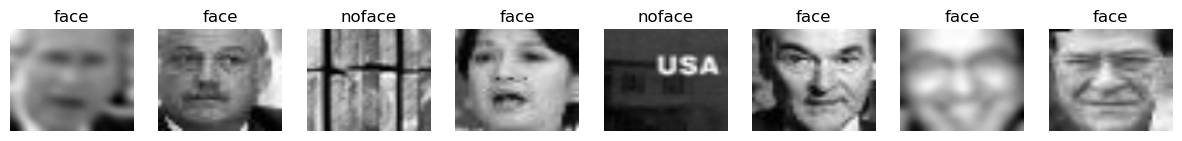

In [29]:
import os
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler
from PIL import Image
import matplotlib.pyplot as plt

# Paths to your dataset
train_dir = r"C:\Users\lingz\Documents\face-detector\deep\data\train_images"    # folder containing training images
test_dir  = r"C:\Users\lingz\Documents\face-detector\deep\data\test_images"     # folder containing test images

# Define transformations (convert to gray-scale, tensor, normalize)
transform = transforms.Compose(
    [transforms.Grayscale(),   # transforms to gray-scale (1 input channel)
     transforms.Resize((92, 112)),  # match the original calculation
     transforms.ToTensor(),    # transforms to Torch tensor (needed for PyTorch)
     transforms.Normalize(mean=(0.5,), std=(0.5,))]) # subtracts mean (0.5) and divides by std (0.5) -> resulting values in (-1, +1)

# Define two pytorch datasets (train/test) 
train_data = torchvision.datasets.ImageFolder(train_dir, transform=transform)
test_data  = torchvision.datasets.ImageFolder(test_dir, transform=transform)

valid_size = 0.2   # proportion of validation set (80% train, 20% validation)
batch_size = 32    

# Define randomly the indices of examples to use for training and for validation
num_train = len(train_data)
indices_train = list(range(num_train))
np.random.shuffle(indices_train)
split_tv = int(np.floor(valid_size * num_train))
# train_new_idx, valid_idx = indices_train[split_tv:], indices_train[:split_tv]
subset_size = 500  # number of images you want to use for quick test
train_new_idx = train_new_idx[:subset_size]
valid_idx = valid_idx[:int(subset_size*0.2)]  # keep 20% for validation

# Define two "samplers" that will randomly pick examples from the training and validation set
train_sampler = SubsetRandomSampler(train_new_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# Dataloaders (take care of loading the data from disk, batch by batch, during training)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=1)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=1)
test_loader  = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=1)

classes = ('noface','face')  # indicates that "1" means "face" and "0" non-face (only used for display)

# Quick check: see number of examples
print(f"Training samples: {len(train_new_idx)}")
print(f"Validation samples: {len(valid_idx)}")
print(f"Test samples: {len(test_data)}")
print(f"Train samples: {len(train_data)}")


# Visualize a few images from the training dataset
def show_images(loader, num_images=8):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, num_images, figsize=(15,3))
    for i in range(num_images):
        img = images[i].squeeze().numpy()  # remove channel dimension
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')
    plt.show()

show_images(train_loader)


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv layers: input channels=1 (grayscale), output channels=16, kernel 3x3
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers (flattened feature maps -> neurons)
        self.fc1 = nn.Linear(32*23*28, 128)  # adjust based on output of conv+pool
        self.fc2 = nn.Linear(128, 2)         # 2 classes: face/no face

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 -> relu -> pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 -> relu -> pool
        x = x.view(x.size(0), -1)  # x.size(0) = batch size
        x = F.relu(self.fc1(x))              # FC1 -> relu
        x = self.fc2(x)                      # FC2 -> output
        return x


In [25]:
# Loss funciton n stuff
import torch.optim as optim

model = SimpleCNN()
criterion = nn.CrossEntropyLoss()  # for 2-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [26]:
from tqdm import tqdm   # tqdm provides a progress bar for loops

n_epochs = 5            # number of times we go through the entire training dataset

for epoch in range(n_epochs):
    model.train()       # put model in training mode (enables dropout, batchnorm updates)
    running_loss = 0.0  # used to accumulate loss to track average loss per epoch
    
    # tqdm() wraps the DataLoader and displays progress / speed / ETA
    # desc shows which epoch we are currently in
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):

        optimizer.zero_grad()   # reset gradients from previous batch update
        outputs = model(images) # forward pass: compute model predictions
        loss = criterion(outputs, labels)  # compute loss comparing prediction vs truth
        
        loss.backward()   # backpropagation: compute gradients
        optimizer.step()  # update model weights
        
        running_loss += loss.item()  # accumulate loss for averaging
    
    # Print the average loss for this epoch
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


Epoch 1/5: 100%|██████████| 16/16 [00:10<00:00,  1.55it/s]


Epoch 1, Loss: 0.4438748797401786


Epoch 2/5: 100%|██████████| 16/16 [00:08<00:00,  1.84it/s]


Epoch 2, Loss: 0.22588251996785402


Epoch 3/5: 100%|██████████| 16/16 [00:08<00:00,  1.80it/s]


Epoch 3, Loss: 0.13456311682239175


Epoch 4/5: 100%|██████████| 16/16 [00:09<00:00,  1.70it/s]


Epoch 4, Loss: 0.08977863925974816


Epoch 5/5: 100%|██████████| 16/16 [00:09<00:00,  1.73it/s]

Epoch 5, Loss: 0.050712465890683234


In [28]:
import torch
from tqdm import tqdm

model.eval()  # evaluation mode
correct = 0
total = 0

with torch.no_grad():  # no gradients needed in testing
    # wrap loader in tqdm for progress bar
    for images, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(images)                          # forward pass
        _, predictions = torch.max(outputs, 1)           # pick class with highest score
        total += labels.size(0)                          # count total samples
        correct += (predictions == labels).sum().item()  # count correct predictions

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")


Testing: 100%|██████████| 239/239 [01:20<00:00,  2.96it/s]

Test Accuracy: 88.44%
